In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ayushdevadiga/test-1/NationalGeographic_2572187_16x9.avif
/kaggle/input/datasets/ayushdevadiga/test-2/German-Shepherd-dog-Alsatian.webp
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.375.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.704.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.8597.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.5740.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.5703.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.7717.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.2618.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.1956.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.5608.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.5646.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.7267.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.5341.jpg
/kaggle/input/datasets/salader/dogsvscats/test/dogs/dog.7792.jp

In [3]:
# Add Input and Activation to your existing imports
import os
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from keras.layers import Dropout, Input, Activation , Rescaling

2026-06-13 23:27:08.853247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781393229.080317      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781393229.146497      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781393229.658293      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781393229.658331      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781393229.658334      58 computation_placer.cc:177] computation placer alr

In [7]:
# ==========================================
# 1.  DATA LOADING
# ==========================================
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/salader/dogsvscats/train',  
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/salader/dogsvscats/test', 
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [5]:
# # ==========================================
# # 2. DATA PREPROCESSING (NORMALIZATION)
# # ==========================================
# # Normalize pixel values from [0, 255] to [0, 1]
# def process(image, label):
#     image = tf.cast(image / 255., tf.float32)
#     return image, label

# train_ds = train_ds.map(process)
# validation_ds = validation_ds.map(process)

In [8]:
# ==========================================
# 4.Caching
# ==========================================

# Optimize loading without saving the whole dataset to RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)


In [9]:
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Lambda
import tensorflow as tf

def build_model(backbone_name='resnet50'):

    inputs = Input(shape=(224, 224, 3))

    # ── Each model has its own preprocessing ──────────
    if backbone_name == 'resnet50':
        x = Lambda(lambda img: resnet_preprocess(img))(inputs)
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        x = Lambda(lambda img: vgg_preprocess(img))(inputs)
        base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    base.trainable = False
    x = base(x, training=False)

    # ── Classification head ────────────────────────────
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

model_resnet = build_model('resnet50')
model_vgg    = build_model('vgg16')
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Training: ResNet50
Epoch 1/10


I0000 00:00:1781393845.870318     165 service.cc:152] XLA service 0x7e58800030d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781393845.870354     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781393845.870357     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781393847.822332     165 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/625 ━━━━━━━━━━━━━━━━━━━━ 48s 78ms/step - accuracy: 0.5312 - loss: 0.9286   

I0000 00:00:1781393852.968354     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.9794 - loss: 0.0560 - val_accuracy: 0.9848 - val_loss: 0.0464
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9887 - loss: 0.0317 - val_accuracy: 0.9892 - val_loss: 0.0302
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9909 - loss: 0.0265 - val_accuracy: 0.9878 - val_loss: 0.0372
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9923 - loss: 0.0203 - val_accuracy: 0.9870 - val_loss: 0.0436
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9931 - loss: 0.0178 - val_accuracy: 0.9878 - val_loss: 0.0356
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9939 - loss: 0.0154 - val_accuracy: 0.9880 - val_loss: 0.0495
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9954 - loss: 0.0128 - val_accuracy: 0.9886 - val_loss: 0.0456
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9947 - loss: 0.0162 - val

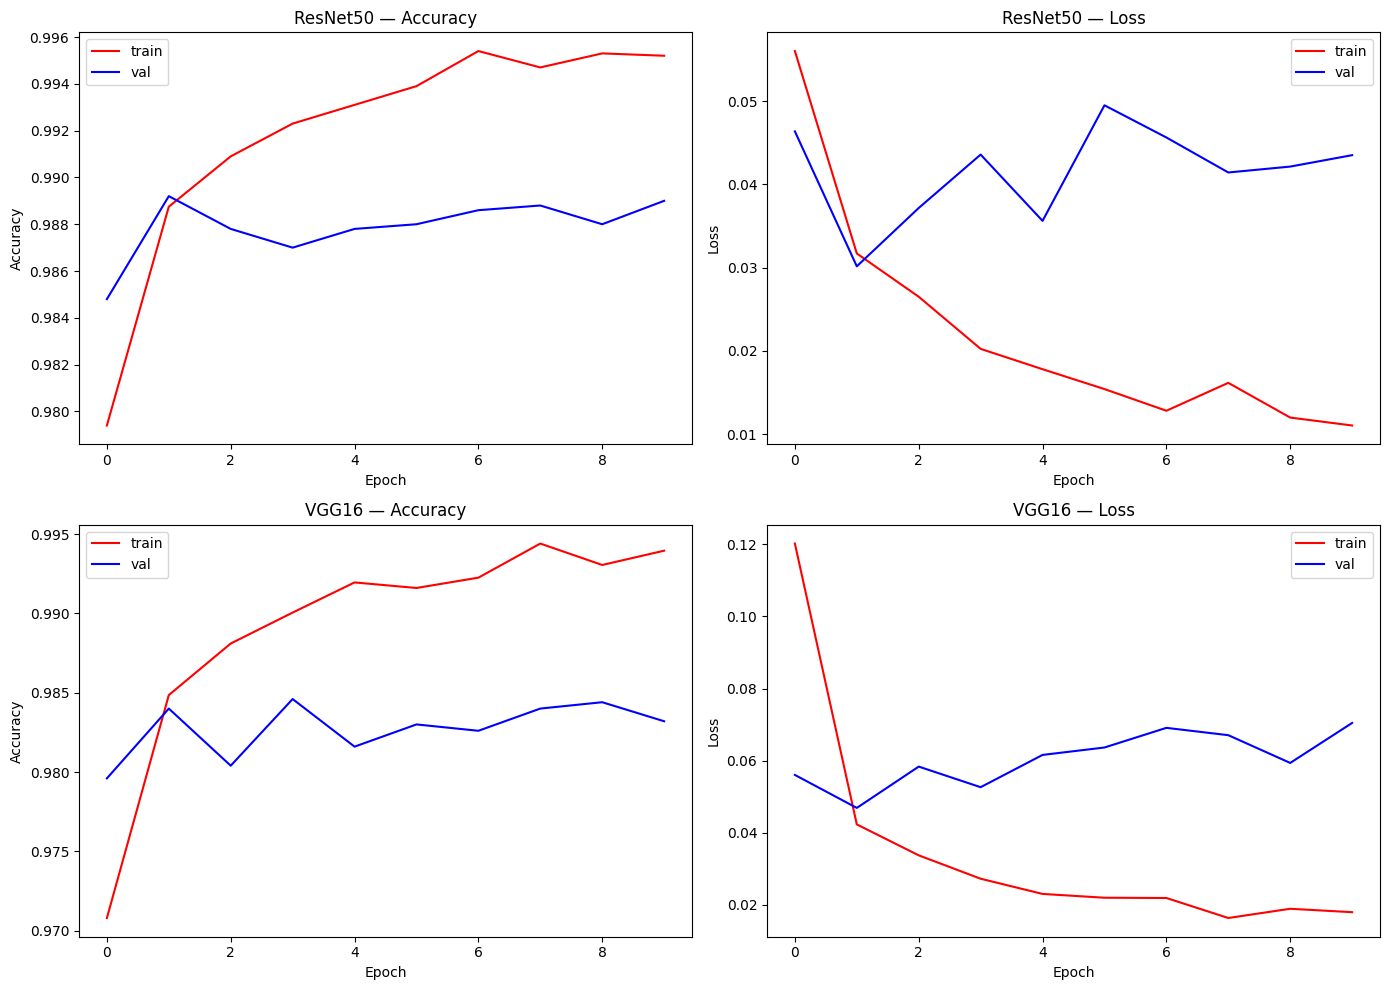


ResNet50  best val accuracy: 0.9892
VGG16     best val accuracy: 0.9846


In [10]:
import matplotlib.pyplot as plt

def train_and_plot(model, name, epochs=10):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print(f"\n{'='*40}")
    print(f"Training: {name}")
    print(f"{'='*40}")
    history = model.fit(train_ds, epochs=epochs, validation_data=validation_ds)
    return history

# Train both
history_resnet = train_and_plot(model_resnet, 'ResNet50')
history_vgg    = train_and_plot(model_vgg,    'VGG16')

# ── Comparison plot ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_row, (hist, name) in enumerate([(history_resnet, 'ResNet50'),
                                        (history_vgg,    'VGG16')]):
    # Accuracy
    axes[ax_row][0].plot(hist.history['accuracy'],     color='red',  label='train')
    axes[ax_row][0].plot(hist.history['val_accuracy'], color='blue', label='val')
    axes[ax_row][0].set_title(f'{name} — Accuracy')
    axes[ax_row][0].set_xlabel('Epoch'); axes[ax_row][0].set_ylabel('Accuracy')
    axes[ax_row][0].legend()

    # Loss
    axes[ax_row][1].plot(hist.history['loss'],     color='red',  label='train')
    axes[ax_row][1].plot(hist.history['val_loss'], color='blue', label='val')
    axes[ax_row][1].set_title(f'{name} — Loss')
    axes[ax_row][1].set_xlabel('Epoch'); axes[ax_row][1].set_ylabel('Loss')
    axes[ax_row][1].legend()

plt.tight_layout()
plt.show()

# ── Final accuracy summary ─────────────────────────────
r_val = max(history_resnet.history['val_accuracy'])
v_val = max(history_vgg.history['val_accuracy'])
print(f"\nResNet50  best val accuracy: {r_val:.4f}")
print(f"VGG16     best val accuracy: {v_val:.4f}")